# AURORA spectra as examples

Download 4 examples from the AURORA survey and get their S/N.

I will use these 4 examples to check the S/N estimated by the JWST ETC.

The sources I will use were shared by Alice Shapley via Slack last year. IDs are

- GOODSN-17940
- GOODSN-100067
- GOODSN-23927
- GOODSN-28209

Shapley reported the following photometry:

| Source | F115W | F125W | F150W | F160W |  r_e  | redshift |
|--------|-------|-------|-------|-------|-------|----------|
| 17940  | 25.01 | 24.97 | 24.81 | 24.81 | 0.161 | 4.4115   |
| 100067 | 25.72 | 25.66 | 25.71 | 25.71 | 0.093 | 5.1875   |
| 23927  | 25.40 | 25.48 | 25.13 | 24.70 | 0.253 | 3.3643   |
| 28209  |  na   | 24.30 |  na   | 24.01 | 0.285 | 3.2325   |

* r_e is the circularized effective radius (which should be sqrt(r_a * r_b)) and was measured on the F227W image.
* The ID is the number in the 3DHST catalog for GOODS-N

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import pandas as pd

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

In [3]:
# function to download file if not present in folder ../data/large
def download_file_if_not_present(filename, url, folder="../data/large"):
    """
    Download a file from a URL if it doesn't already exist in the specified folder.
    """ 
    import os
    import requests

    # check if file exists in folder ../data/large
    if not os.path.exists(f"{folder}/{filename}"):
        print(f"Downloading {filename} from {url}...")
        response = requests.get(url)
        with open(f"{folder}/{filename}", "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename} to {folder}")
    else:
        print(f"{filename} already exists in {folder}, skipping download.")

In [4]:
version = "v4.4" # Updated September 5, 2025.  Include all public spectra even without redshift / line fits

URL_PREFIX = "https://s3.amazonaws.com/msaexp-nirspec/extractions"
FILE_NAME = f"dja_msaexp_emission_lines_{version}.csv.gz"
table_url = f"{URL_PREFIX}/{FILE_NAME}"
download_file_if_not_present(FILE_NAME, table_url, folder="../data/large")

nirspec_table = Table.read(f"../data/large/{FILE_NAME}", format="csv").to_pandas()

dja_msaexp_emission_lines_v4.4.csv.gz already exists in ../data/large, skipping download.


In [5]:
src_id_list = [17940, 100067, 23927, 28209]

selection = nirspec_table.query("(root=='aurora-gdn01-v4' or root=='aurora-gdn02-v4') and srcid in @src_id_list and filter=='F100LP'")
selection[['file', 'srcid', 'root', 'z_best', 'zgrade', 'grade', 'comment']]

,file,srcid,root,z_best,zgrade,grade,comment
1886,aurora-gdn02-v4_g140m-f100lp_1914_100067.spec....,100067,aurora-gdn02-v4,5.188222,5.18850,3,Redshift matches aurora-gdn02-v3_g140m-f100lp_...
1898,aurora-gdn02-v4_g140m-f100lp_1914_17940.spec.fits,17940,aurora-gdn02-v4,4.412871,NaN,<NA>,NaN
1907,aurora-gdn02-v4_g140m-f100lp_1914_23927.spec.fits,23927,aurora-gdn02-v4,3.363388,3.36358,3,Redshift matches aurora-gdn02-v3_g235m-f170lp_...
1911,aurora-gdn02-v4_g140m-f100lp_1914_28209.spec.fits,28209,aurora-gdn02-v4,3.234066,3.23410,3,Redshift matches aurora-gdn02-v3_g235m-f170lp_...


In [6]:
FITS_URL = "https://s3.amazonaws.com/msaexp-nirspec/extractions/{root}/{file}"

root = selection.root.iloc[0]
fname = selection.file.iloc[0]

for root, fname in zip(selection.root, selection.file):
    # print(FITS_URL.format(root=root, file=fname))
    download_file_if_not_present(fname, FITS_URL.format(root=root, file=fname), folder="../data/large")

aurora-gdn02-v4_g140m-f100lp_1914_100067.spec.fits already exists in ../data/large, skipping download.
aurora-gdn02-v4_g140m-f100lp_1914_17940.spec.fits already exists in ../data/large, skipping download.
aurora-gdn02-v4_g140m-f100lp_1914_23927.spec.fits already exists in ../data/large, skipping download.
aurora-gdn02-v4_g140m-f100lp_1914_28209.spec.fits already exists in ../data/large, skipping download.


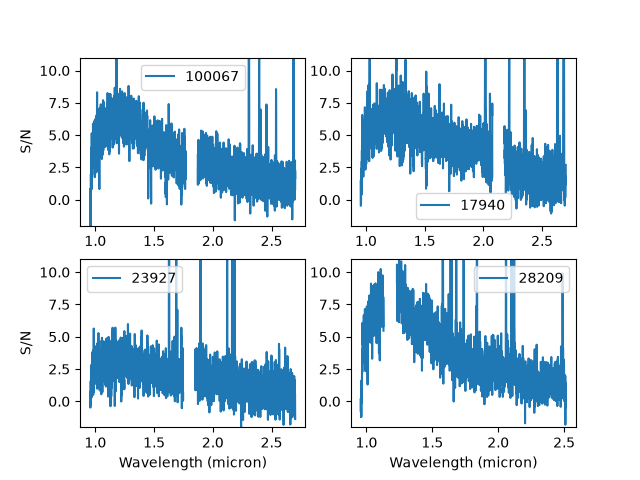

In [7]:
a = fits.open('../data/large/aurora-gdn02-v4_g140m-f100lp_1914_17940.spec.fits')

plt.figure(1)
plt.clf()

ax_list = plt.subplots(nrows=2, ncols=2, num=1, clear=True)[1].flatten()

for ax, fname in zip(ax_list, selection.file):
    idx = fname.split('_')[-1].split('.')[0]
    with fits.open(f'../data/large/{fname}') as spec1d:
        ax.plot(spec1d[1].data['wave'], spec1d[1].data['flux'] / spec1d[1].data['err'], label=idx)
    ax.legend()
    ax.set_ylim(-2, 11)

ax_list[2].set_xlabel('Wavelength (micron)')
ax_list[3].set_xlabel('Wavelength (micron)')
ax_list[0].set_ylabel('S/N')
ax_list[2].set_ylabel('S/N')

plt.show()

In [8]:
selection[['srcid', 'objid', 'ra', 'dec', 'file_phot', 'id_phot', 'zline', 'z_best', 'phot_flux_radius', 'phot_f150w_tot_1']]

,srcid,objid,ra,dec,file_phot,id_phot,zline,z_best,phot_flux_radius,phot_f150w_tot_1
1886,100067,160385,189.234790,62.257483,gdn-grizli-v7.4-fix_phot.fits,58988,5.188497,5.188222,5.30,0.272446
1898,17940,173212,189.147847,62.230567,gdn-grizli-v7.4-fix_phot.fits,43589,4.411448,4.412871,7.28,0.550040
1907,23927,160408,189.241053,62.259512,gdn-grizli-v7.4-fix_phot.fits,60115,3.363582,3.363388,7.36,0.451683
1911,28209,173188,189.188425,62.281180,gdn-grizli-v7.4-fix_phot.fits,71535,3.234102,3.234066,6.17,-99.000000


## Getting the photometry

The photometry in the NirSpec merged catalog comes from v7.4 of the phot catalog. But the info I have from Shapley is based on v7.3. I want to be able to compare with that first, so I will do this based on v7.3 which means, I cannot use the `id_phot` column, which would have been very useful. Instead, I will have to match by position.

In [9]:
expected_mags = pd.DataFrame({
    'm115w': [25.01, 25.72, 25.40, np.nan],
    'm125w': [24.97, 25.66, 25.48, 24.30],
    'm150w': [24.81, 25.71, 25.13, np.nan],
    'm160w': [24.81, 25.71, 24.70, 24.01] },
    index=[17940, 100067, 23927, 28209])

expected_mags

,m115w,m125w,m150w,m160w
17940,25.01,24.97,24.81,24.81
100067,25.72,25.66,25.71,25.71
23927,25.40,25.48,25.13,24.70
28209,NaN,24.30,NaN,24.01


In [10]:
url_path = 'https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7'
field = 'gdn-grizli-v7.3'  # There's a v7.4 but Shapley used 7.3 so use that one to compare first
phot_file = f'{field}-fix_phot_apcorr.fits'
zero_point_file = f'{field}-fix.eazypy.zphot.zeropoint'

download_file_if_not_present(phot_file, f'{url_path}/{phot_file}', folder="../data/large")
download_file_if_not_present(zero_point_file, f'{url_path}/{zero_point_file}', folder="../data/large")

gdn-grizli-v7.3-fix_phot_apcorr.fits already exists in ../data/large, skipping download.
gdn-grizli-v7.3-fix.eazypy.zphot.zeropoint already exists in ../data/large, skipping download.


In [11]:
phot = Table.read(f'../data/large/{phot_file}', format='fits').to_pandas()

In [12]:
zeropoint_corrs = np.array([0.799038, 0.868089, 0.794497, 0.893685])  # f115, f125, f150, f160 from the zeropoint file

In [13]:
spec_coords = SkyCoord(ra=selection.ra.values * u.deg, dec=selection.dec.values * u.deg)
phot_coords = SkyCoord(ra=phot.ra.values * u.deg, dec=phot.dec.values * u.deg)

idx, d2d, d3d = spec_coords.match_to_catalog_sky(phot_coords)
print(d2d.to(u.arcsec))

[0.123085 arcsec 0.0318103 arcsec 0.122231 arcsec 0.0734613 arcsec]


The matches are good.

In [14]:
matched_phot = phot.iloc[idx].set_index(selection.srcid.values)

In [15]:
matched_phot['f150w_tot_1']

100067     0.246931
17940      0.551607
23927      0.419461
28209    -99.000000
Name: f150w_tot_1, dtype: float64

In [16]:
selection[['srcid', 'objid', 'ra', 'dec', 'file_phot', 'id_phot', 'zline', 'z_best', 'phot_flux_radius', 'phot_f150w_tot_1']]

,srcid,objid,ra,dec,file_phot,id_phot,zline,z_best,phot_flux_radius,phot_f150w_tot_1
1886,100067,160385,189.234790,62.257483,gdn-grizli-v7.4-fix_phot.fits,58988,5.188497,5.188222,5.30,0.272446
1898,17940,173212,189.147847,62.230567,gdn-grizli-v7.4-fix_phot.fits,43589,4.411448,4.412871,7.28,0.550040
1907,23927,160408,189.241053,62.259512,gdn-grizli-v7.4-fix_phot.fits,60115,3.363582,3.363388,7.36,0.451683
1911,28209,173188,189.188425,62.281180,gdn-grizli-v7.4-fix_phot.fits,71535,3.234102,3.234066,6.17,-99.000000


I can see that there are some small differences between v7.3 and v7.4 photometry.

The bands that I have info from Shapley are `f115w`, `f125w`, `f150w`, `f160w`

In [17]:
matched_phot[['f115w_tot_1', 'f125w_tot_1', 'f150w_tot_1', 'f160w_tot_1']]

,f115w_tot_1,f125w_tot_1,f150w_tot_1,f160w_tot_1
100067,0.239410,0.238221,0.246931,0.220809
17940,0.468195,0.434957,0.551607,0.491521
23927,0.315384,0.279701,0.419461,0.375061
28209,0.715272,0.710965,-99.000000,0.909370


In [18]:
v73mags = 23.9 - 2.5 * np.log10(matched_phot[['f115w_tot_1', 'f125w_tot_1', 'f150w_tot_1', 'f160w_tot_1']] * zeropoint_corrs)
v73mags = v73mags.rename(columns={'f115w_tot_1': 'm115w', 'f125w_tot_1': 'm125w', 'f150w_tot_1': 'm150w', 'f160w_tot_1': 'm160w'})
v73mags

/Users/tino/repos/jwst-C6-UV-absorption/.venv/lib/python3.12/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


,m115w,m125w,m150w,m160w
100067,25.695727,25.611139,25.668328,25.661995
17940,24.967514,24.957473,24.795696,24.793184
23927,25.396482,25.436853,25.093040,25.086784
28209,24.507403,24.423969,NaN,24.125187


In [19]:
expected_mags

,m115w,m125w,m150w,m160w
17940,25.01,24.97,24.81,24.81
100067,25.72,25.66,25.71,25.71
23927,25.40,25.48,25.13,24.70
28209,NaN,24.30,NaN,24.01


In [20]:
v73mags - expected_mags

,m115w,m125w,m150w,m160w
17940,-0.042486,-0.012527,-0.014304,-0.016816
23927,-0.003518,-0.043147,-0.036960,0.386784
28209,NaN,0.123969,NaN,0.115187
100067,-0.024273,-0.048861,-0.041672,-0.048005


The agreement is decent although there is one case of a 0.39 mag difference in 160w. Most of the others are OK.

What about v7.4?

In [21]:
field = 'gdn-grizli-v7.4'
phot_file = f'{field}-fix_phot_apcorr.fits'
phot = Table.read(f'../data/large/{phot_file}', format='fits').to_pandas()
spec_coords = SkyCoord(ra=selection.ra.values * u.deg, dec=selection.dec.values * u.deg)
phot_coords = SkyCoord(ra=phot.ra.values * u.deg, dec=phot.dec.values * u.deg)

idx, d2d, d3d = spec_coords.match_to_catalog_sky(phot_coords)
matched_phot = phot.iloc[idx].set_index(selection.srcid.values)
v74mags = 23.9 - 2.5 * np.log10(matched_phot[['f115w_tot_1', 'f125w_tot_1', 'f150w_tot_1', 'f160w_tot_1']] * zeropoint_corrs)
v74mags = v74mags.rename(columns={'f115w_tot_1': 'm115w', 'f125w_tot_1': 'm125w', 'f150w_tot_1': 'm150w', 'f160w_tot_1': 'm160w'})


/Users/tino/repos/jwst-C6-UV-absorption/.venv/lib/python3.12/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


In [22]:
v74mags - expected_mags

,m115w,m125w,m150w,m160w
17940,0.062193,0.093999,-0.011215,0.041915
23927,-0.061625,-0.051524,-0.117315,0.378456
28209,NaN,0.094263,NaN,0.092325
100067,-0.135474,-0.093074,-0.148430,-0.089246


Comparable differences, not a bit change from v7.4 to v7.3. Sticking to v7.3.